# Tugas 13 — Memahami Alur Belajar Neural Network

**Kelompok :** 3   
**Anggota 1 :** Syarifah Nesia (2024091017) - TEKNIK SIPIL   
**Anggota 2 :** Panji Kurnia Akbar (2024081024) - SISTEM INFORMASI    
**Mata Kuliah:** Introduction to AI

---

## Kasus yang Dipilih: Klasifikasi Judul Berita

Kita akan mengklasifikasikan **judul berita** ke dalam dua kelas:

| Label | Kelas | Arti |
|-------|-------|------|
| `1` | **Berita Kriminal** | Judul berita yang mengandung unsur kejahatan, pelanggaran hukum, atau tindak kriminal |
| `0` | **Berita Non-Kriminal** | Judul berita umum — politik, sosial, ekonomi, dll |

**Kenapa memilih judul berita?**  
Karena setiap hari kita disuguhi ratusan headline berita, dan sering kali susah membedakan mana yang mengandung konten kriminal atau bukan hanya dari judulnya saja. Nah, dengan neural network, kita bisa bantu otomatisasi itu!

---
## 1. Import Library

Pertama-tama, kita import semua library yang dibutuhkan. Library-library ini adalah "senjata utama" kita dalam membangun dan mengevaluasi model neural network.

- **pandas** → untuk baca dan olah data berbentuk tabel
- **numpy** → operasi numerik dan array
- **sklearn** → toolkit machine learning: model, preprocessing, evaluasi
- **matplotlib & seaborn** → untuk bikin visualisasi yang informatif
- **IPython.display** → buat nampilin output lebih rapi di notebook

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from IPython.display import display

# Setting style visualisasi
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('✅ Semua library berhasil di-import!')

✅ Semua library berhasil di-import!


---
## 2. Load Dataset

Kita load dataset judul berita yang sudah disiapkan. Dataset ini berisi **10 data** judul berita nyata yang sudah dilabeli manual.

Dataset ini punya format kolom berikut:
- `id` → ID unik tiap berita (D1 sampai D10)
- `judul_berita` → judul asli berita
- `kata_kriminal` → jumlah kata/frasa yang berkaitan dengan kriminalitas
- `kata_umum` → jumlah kata umum yang netral
- `kata_urgensi` → jumlah kata yang mengandung urgensi / intensitas tinggi
- `label_kelas` → label target: **1 = Kriminal**, **0 = Non-Kriminal**

In [5]:
# Load dataset
df = pd.read_csv('dataset_berita_tugas13.csv', sep=';')

# Tampilkan info dasar
print(f' Jumlah data : {df.shape[0]} baris')
print(f' Jumlah kolom: {df.shape[1]} kolom')
print(f' Nama kolom  : {df.columns.tolist()}')
print()
print(df.dtypes)

 Jumlah data : 10 baris
 Jumlah kolom: 6 kolom
 Nama kolom  : ['id', 'judul_berita', 'kata_kriminal', 'kata_umum', 'kata_urgensi', 'label_kelas']

id                 str
judul_berita       str
kata_kriminal    int64
kata_umum        int64
kata_urgensi     int64
label_kelas      int64
dtype: object


---
## 3. Tabel Data

Berikut adalah seluruh data yang kita gunakan — 10 judul berita lengkap dengan fitur dan labelnya.

In [6]:
# Tampilkan tabel data lengkap
df_display = df.copy()
df_display['label_nama'] = df_display['label_kelas'].map({1: '🔴 Kriminal', 0: '🟢 Non-Kriminal'})

print('=' * 90)
print('                        TABEL DATASET BERITA TUGAS 13')
print('=' * 90)
display(df_display[['id', 'judul_berita', 'kata_kriminal', 'kata_umum', 'kata_urgensi', 'label_nama']]
        .rename(columns={
            'id': 'ID',
            'judul_berita': 'Judul Berita',
            'kata_kriminal': 'Kata Kriminal',
            'kata_umum': 'Kata Umum',
            'kata_urgensi': 'Kata Urgensi',
            'label_nama': 'Label Kelas'
        })
        .style.set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold'), ('background-color', "#2b3347")]}]))

print()
print(f'Total data Kriminal     : {(df["label_kelas"] == 1).sum()} data')
print(f'Total data Non-Kriminal : {(df["label_kelas"] == 0).sum()} data')

                        TABEL DATASET BERITA TUGAS 13


,ID,Judul Berita,Kata Kriminal,Kata Umum,Kata Urgensi,Label Kelas
0,D1,"""Kebakaran Hebat di Kemayoran Jakpus, 250 Rumah Warga Hangus""",0,2,2,🟢 Non-Kriminal
1,D2,"""Prabowo-Megawati Gandengan, Bos PPI: Hubungan Mereka Melampaui Urusan Politik""",0,3,1,🟢 Non-Kriminal
2,D3,"""Akhir Aksi Pria Bogor Tipu-tipu Modus Tarik Tunai di SPBU""",2,2,2,🔴 Kriminal
3,D4,"""Pejabat Tembak Sapi Kurban Idul Adha Pakai Senapan, Publik Malaysia Terbelah""",1,3,1,🟢 Non-Kriminal
4,D5,"""Babak Baru Kasus Pembubaran Ibadah Jemaat Gereja di Bantul""",2,2,1,🔴 Kriminal
5,D6,"""Kronologi Pembunuhan WN Korsel yang Didalangi Mantan Istri""",2,1,1,🔴 Kriminal
6,D7,"""Viral Maling Kepergok Curi Motor di Jaktim hingga Todongkan Pistol""",2,1,3,🔴 Kriminal
7,D8,"""Rano: Saya Surprised Perbaikan Jalan Amblas Lenteng Agung Hanya Butuh 5 Hari""",0,3,2,🟢 Non-Kriminal
8,D9,"""Kenapa Investasi ke TaniHub Dianggap Rugikan Negara Rp 364 M? Ini Dakwaan Jaksa""",2,2,2,🔴 Kriminal
9,D10,"""Berkas Perkara Lengkap, Roy Suryo Segera Disidang di Kasus Ijazah Jokowi""",3,2,2,🔴 Kriminal



Total data Kriminal     : 6 data
Total data Non-Kriminal : 4 data


---
## 4. Label Kelas & Distribusi Data

### Dua Kelas Target

| Kelas | Label | Contoh Judul |
|-------|-------|--------------|
| **Non-Kriminal** | 0 | "Prabowo-Megawati Gandengan, Bos PPI: Hubungan Mereka Melampaui Urusan Politik" |
| **Kriminal** | 1 | "Kronologi Pembunuhan WN Korsel yang Didalangi Mantan Istri" |

Kita visualisasikan distribusi kelas dan pola fitur dari dataset:

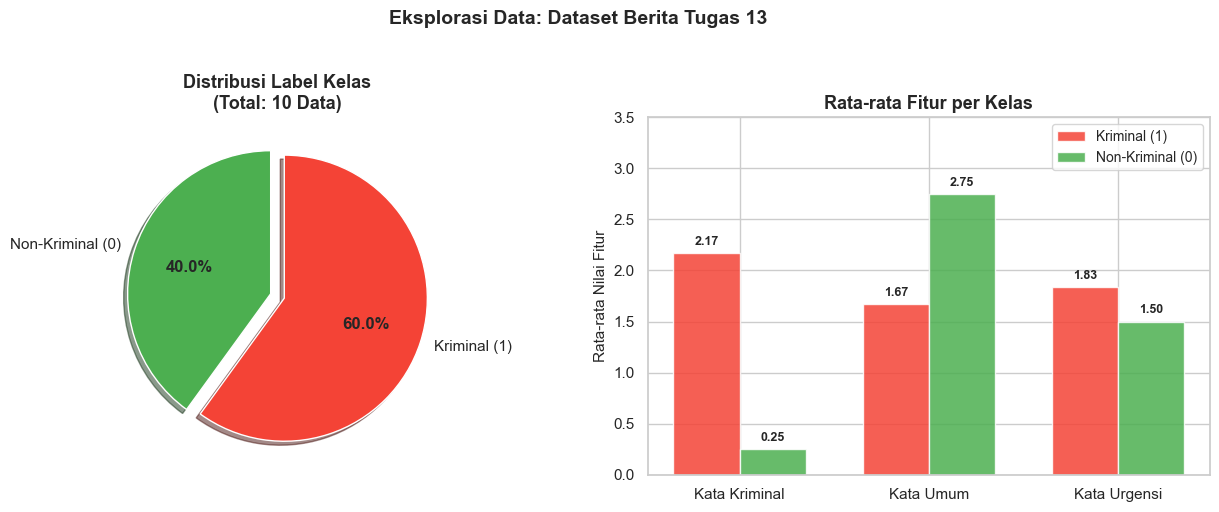

📊 Visualisasi distribusi kelas dan fitur selesai!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Distribusi Kelas ---
kelas_counts = df['label_kelas'].value_counts()
kelas_labels = ['Non-Kriminal (0)', 'Kriminal (1)']
colors_pie = ['#4CAF50', '#F44336']

wedges, texts, autotexts = axes[0].pie(
    [kelas_counts.get(0, 0), kelas_counts.get(1, 0)],
    labels=kelas_labels,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    explode=(0.05, 0.05),
    shadow=True
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[0].set_title('Distribusi Label Kelas\n(Total: 10 Data)', fontsize=13, fontweight='bold')

# --- Plot 2: Rata-rata Fitur per Kelas ---
fitur = ['kata_kriminal', 'kata_umum', 'kata_urgensi']
means_kriminal = df[df['label_kelas'] == 1][fitur].mean().values
means_non = df[df['label_kelas'] == 0][fitur].mean().values

x = np.arange(len(fitur))
w = 0.35
axes[1].bar(x - w/2, means_kriminal, width=w, label='Kriminal (1)', color='#F44336', alpha=0.85)
axes[1].bar(x + w/2, means_non, width=w, label='Non-Kriminal (0)', color='#4CAF50', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Kata Kriminal', 'Kata Umum', 'Kata Urgensi'], fontsize=11)
axes[1].set_ylabel('Rata-rata Nilai Fitur', fontsize=11)
axes[1].set_title('Rata-rata Fitur per Kelas', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 3.5)
for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{bar.get_height():.2f}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

plt.suptitle('Eksplorasi Data: Dataset Berita Tugas 13', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_distribusi_kelas.png', bbox_inches='tight', dpi=120)
plt.show()
print('📊 Visualisasi distribusi kelas dan fitur selesai!')

---
## 5. Penjelasan Fitur yang Digunakan

Model neural network kita tidak langsung membaca teks judul berita mentah-mentah. Kita ekstrak dulu **3 fitur numerik** dari setiap judul berita:

| Fitur | Deskripsi | Contoh Kata/Frasa yang Dihitung |
|-------|-----------|----------------------------------|
| `kata_kriminal` | Jumlah kata/frasa yang secara langsung berkaitan dengan tindak kriminal | pembunuhan, pencurian, tipu, maling, tembak, perkara |
| `kata_umum` | Jumlah kata netral/umum — tidak spesifik ke kriminal atau sensitif | kasus, pejabat, viral, investasi, hubungan, perbaikan |
| `kata_urgensi` | Jumlah kata yang mengandung intensitas atau urgensi tinggi | hebat, hangus, babak baru, kronologi, kepergok, segera |

**Kenapa fitur ini dipilih?**  
Karena ketiga fitur ini mencerminkan "sinyal" yang berbeda dalam sebuah judul berita:
- Kalau `kata_kriminal` tinggi → kemungkinan besar berita kriminal
- Kalau `kata_umum` tinggi tanpa `kata_kriminal` → kemungkinan berita non-kriminal
- `kata_urgensi` membantu model menangkap intensitas bahasa yang sering muncul di berita kriminal

Neural network akan belajar sendiri bagaimana **kombinasi** ketiga fitur ini menentukan kelas!

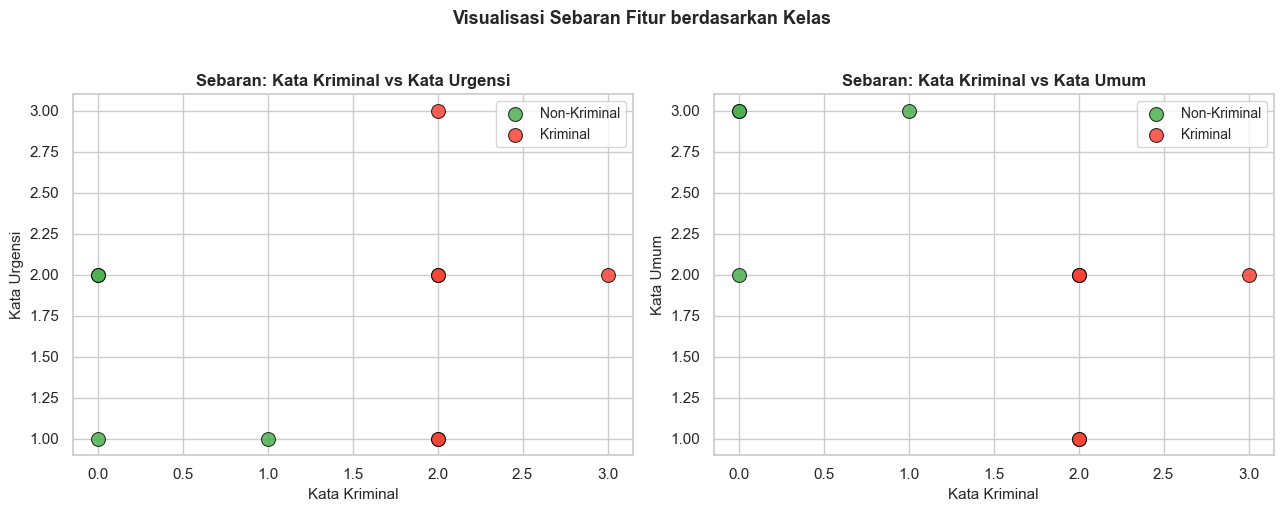

📊 Scatter plot fitur selesai ditampilkan!


In [8]:
# Visualisasi scatter plot fitur kata_kriminal vs kata_urgensi
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_map = {0: '#4CAF50', 1: '#F44336'}
label_map = {0: 'Non-Kriminal', 1: 'Kriminal'}

# Scatter: kata_kriminal vs kata_urgensi
for label_val in [0, 1]:
    subset = df[df['label_kelas'] == label_val]
    axes[0].scatter(
        subset['kata_kriminal'], subset['kata_urgensi'],
        c=colors_map[label_val], label=label_map[label_val],
        s=100, edgecolors='black', linewidths=0.7, alpha=0.85
    )
axes[0].set_xlabel('Kata Kriminal', fontsize=11)
axes[0].set_ylabel('Kata Urgensi', fontsize=11)
axes[0].set_title('Sebaran: Kata Kriminal vs Kata Urgensi', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Scatter: kata_kriminal vs kata_umum
for label_val in [0, 1]:
    subset = df[df['label_kelas'] == label_val]
    axes[1].scatter(
        subset['kata_kriminal'], subset['kata_umum'],
        c=colors_map[label_val], label=label_map[label_val],
        s=100, edgecolors='black', linewidths=0.7, alpha=0.85
    )
axes[1].set_xlabel('Kata Kriminal', fontsize=11)
axes[1].set_ylabel('Kata Umum', fontsize=11)
axes[1].set_title('Sebaran: Kata Kriminal vs Kata Umum', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Visualisasi Sebaran Fitur berdasarkan Kelas', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_sebaran_fitur.png', bbox_inches='tight', dpi=120)
plt.show()
print('📊 Scatter plot fitur selesai ditampilkan!')

---
## 6. Preprocessing Data

Sebelum data masuk ke model, kita perlu **preprocessing** dulu. Di sini ada dua langkah:

1. **Memisahkan fitur (X) dan label (y)** — X adalah input model, y adalah target yang ingin diprediksi
2. **StandardScaler** — menyamakan skala semua fitur supaya tidak ada fitur yang "mendominasi" hanya karena nilainya lebih besar

Kenapa perlu scaling? Karena neural network sensitif terhadap skala input — kalau tidak discale, bobot bisa bias ke fitur dengan nilai terbesar.

In [9]:
# Pisahkan fitur dan label
fitur_kolom = ['kata_kriminal', 'kata_umum', 'kata_urgensi']
X = df[fitur_kolom].values
y = df['label_kelas'].values

print('Fitur Input (X) — sebelum scaling:')
print(pd.DataFrame(X, columns=fitur_kolom).to_string(index=False))
print()
print('Label Target (y):')
print(y)
print()

# Scaling fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Fitur Input (X) — setelah StandardScaler:')
print(pd.DataFrame(X_scaled, columns=fitur_kolom).round(4).to_string(index=False))
print()
print('✅ Preprocessing selesai!')

Fitur Input (X) — sebelum scaling:
 kata_kriminal  kata_umum  kata_urgensi
             0          2             2
             0          3             1
             2          2             2
             1          3             1
             2          2             1
             2          1             1
             2          1             3
             0          3             2
             2          2             2
             3          2             2

Label Target (y):
[0 0 1 0 1 1 1 0 1 1]

Fitur Input (X) — setelah StandardScaler:
 kata_kriminal  kata_umum  kata_urgensi
       -1.3728    -0.1429        0.4685
       -1.3728     1.2857       -1.0932
        0.5883    -0.1429        0.4685
       -0.3922     1.2857       -1.0932
        0.5883    -0.1429       -1.0932
        0.5883    -1.5714       -1.0932
        0.5883    -1.5714        2.0303
       -1.3728     1.2857        0.4685
        0.5883    -0.1429        0.4685
        1.5689    -0.1429        0.4685



---
## 7. Split Data: Training & Testing

Data kita bagi jadi dua:
- **Training set (75%)** — dipakai untuk melatih model neural network
- **Testing set (25%)** — dipakai untuk mengevaluasi seberapa bagus model setelah dilatih

Kenapa perlu dibagi? Supaya kita tahu apakah model beneran **belajar** atau cuma hafal data latih aja (overfitting).

In [10]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

print(f'✅ Split berhasil!')
print(f'   🔵 Training set : {X_train.shape[0]} data ({(X_train.shape[0] / len(y)) * 100:.0f}%)')
print(f'   🟠 Testing set  : {X_test.shape[0]} data ({(X_test.shape[0] / len(y)) * 100:.0f}%)')
print()
print('   Label training :', y_train)
print('   Label testing  :', y_test)

✅ Split berhasil!
   🔵 Training set : 7 data (70%)
   🟠 Testing set  : 3 data (30%)

   Label training : [0 0 1 1 1 0 1]
   Label testing  : [1 0 1]


---
## 8. Membangun & Melatih Model Neural Network (MLPClassifier)

Kita pakai **MLPClassifier** dari scikit-learn — ini adalah implementasi Multi-Layer Perceptron (jenis neural network).

### Konfigurasi Model:
| Parameter | Nilai | Penjelasan |
|-----------|-------|------------|
| `hidden_layer_sizes` | `(5, 3)` | 2 hidden layer: layer pertama 5 neuron, layer kedua 3 neuron |
| `activation` | `relu` | Fungsi aktivasi ReLU di hidden layer — lebih efisien dari sigmoid |
| `solver` | `adam` | Optimizer Adam — cerdas dalam mengatur learning rate |
| `max_iter` | `1000` | Maksimum 1000 iterasi training |
| `random_state` | `42` | Seed agar hasil bisa direproduksi |

### Alur Lengkap Cara Neural Network Belajar:

**1. Input →** Data fitur (kata_kriminal, kata_umum, kata_urgensi) masuk ke input layer  
**2. Forward Propagation →** Data diteruskan dari input → hidden layer 1 → hidden layer 2 → output layer, setiap neuron menghitung `z = (input × bobot) + bias`, lalu masuk fungsi aktivasi  
**3. Output →** Model menghasilkan prediksi: probabilitas kelas Kriminal (1) atau Non-Kriminal (0)  
**4. Error / Loss →** Prediksi dibandingkan dengan label asli, dihitung selisihnya (loss)  
**5. Backpropagation →** Error dikirim mundur dari output → hidden layer → input, menghitung kontribusi kesalahan tiap bobot  
**6. Gradient Descent →** Bobot diperbarui sedikit demi sedikit ke arah yang meminimalkan error  
**7. Ulangi →** Proses diulang sampai max_iter atau error cukup kecil

In [11]:
# Bangun model
model = MLPClassifier(
    hidden_layer_sizes=(5, 3),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    verbose=False
)

# Training
model.fit(X_train, y_train)

print('✅ Model berhasil dilatih!')
print(f'    Iterasi yang dibutuhkan : {model.n_iter_} iterasi')
print(f'    Loss akhir training     : {model.loss_:.6f}')
print()
print('Arsitektur Neural Network:')
print(f'   Input Layer   : {X_train.shape[1]} neuron (jumlah fitur)')
print(f'   Hidden Layer 1: 5 neuron (aktivasi: ReLU)')
print(f'   Hidden Layer 2: 3 neuron (aktivasi: ReLU)')
print(f'   Output Layer  : 1 neuron (aktivasi: Sigmoid → output probabilitas)')

✅ Model berhasil dilatih!
    Iterasi yang dibutuhkan : 795 iterasi
    Loss akhir training     : 0.018780

Arsitektur Neural Network:
   Input Layer   : 3 neuron (jumlah fitur)
   Hidden Layer 1: 5 neuron (aktivasi: ReLU)
   Hidden Layer 2: 3 neuron (aktivasi: ReLU)
   Output Layer  : 1 neuron (aktivasi: Sigmoid → output probabilitas)


---
## 9. Visualisasi Arsitektur Neural Network

Berikut adalah gambaran visual dari arsitektur neural network yang kita bangun — dari input sampai output:

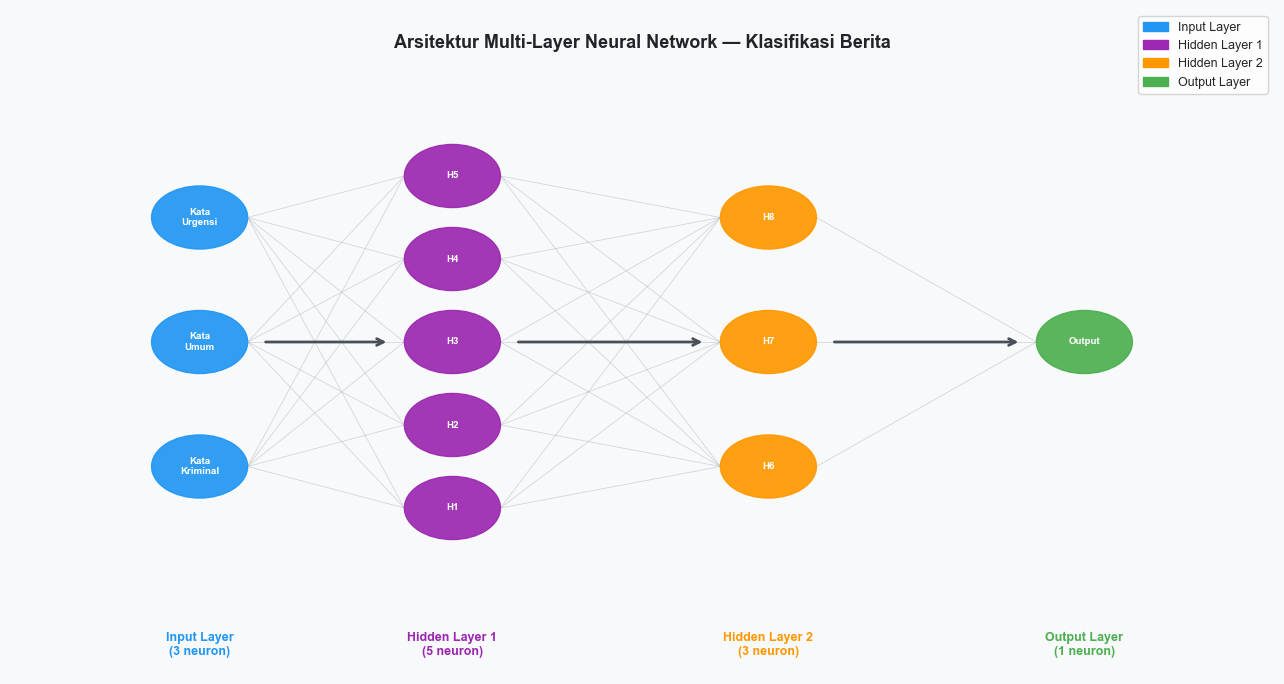

📊 Visualisasi arsitektur neural network selesai!


In [12]:
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

layer_x = [1.5, 3.5, 6.0, 8.5]
layer_neurons = [3, 5, 3, 1]
layer_labels = ['Input Layer\n(3 neuron)', 'Hidden Layer 1\n(5 neuron)', 'Hidden Layer 2\n(3 neuron)', 'Output Layer\n(1 neuron)']
layer_colors = ['#2196F3', '#9C27B0', '#FF9800', '#4CAF50']
neuron_names = [
    ['Kata\nKriminal', 'Kata\nUmum', 'Kata\nUrgensi'],
    ['H1', 'H2', 'H3', 'H4', 'H5'],
    ['H6', 'H7', 'H8'],
    ['Output']
]

neuron_positions = []
for i, (lx, n_neurons, color) in enumerate(zip(layer_x, layer_neurons, layer_colors)):
    positions = []
    spacing = 6.0 / (n_neurons + 1)
    for j in range(n_neurons):
        cy = 1.0 + (j + 1) * spacing
        positions.append((lx, cy))
        circle = plt.Circle((lx, cy), 0.38, color=color, zorder=3, alpha=0.92)
        ax.add_patch(circle)
        label = neuron_names[i][j]
        ax.text(lx, cy, label, ha='center', va='center', fontsize=7, fontweight='bold',
                color='white', zorder=4)
    neuron_positions.append(positions)

# Gambar koneksi antar layer
for i in range(len(neuron_positions) - 1):
    for pos1 in neuron_positions[i]:
        for pos2 in neuron_positions[i + 1]:
            ax.plot([pos1[0] + 0.38, pos2[0] - 0.38],
                    [pos1[1], pos2[1]],
                    color='#adb5bd', linewidth=0.6, alpha=0.5, zorder=1)

# Label layer
for lx, label, color in zip(layer_x, layer_labels, layer_colors):
    ax.text(lx, 0.35, label, ha='center', va='center', fontsize=9,
            fontweight='bold', color=color)

# Panah alur
for i in range(len(layer_x) - 1):
    ax.annotate('', xy=(layer_x[i + 1] - 0.5, 4.0),
                xytext=(layer_x[i] + 0.5, 4.0),
                arrowprops=dict(arrowstyle='->', color='#495057', lw=2))

ax.text(5.0, 7.6, 'Arsitektur Multi-Layer Neural Network — Klasifikasi Berita',
        ha='center', va='center', fontsize=13, fontweight='bold', color='#212529')

# Legend
legend_patches = [mpatches.Patch(color=c, label=l.split('\n')[0])
                  for c, l in zip(layer_colors, layer_labels)]
ax.legend(handles=legend_patches, loc='upper right', fontsize=9, framealpha=0.8)

plt.tight_layout()
plt.savefig('plot_arsitektur_nn.png', bbox_inches='tight', dpi=120)
plt.show()
print('📊 Visualisasi arsitektur neural network selesai!')

---
## 10. Ilustrasi Forward Propagation (Manual)

Supaya kita benar-benar paham proses **forward propagation**, kita hitung manual satu contoh dari dataset kita.

Kita ambil **D7**: *"Viral Maling Kepergok Curi Motor di Jaktim hingga Todongkan Pistol"*
- `kata_kriminal = 2`, `kata_umum = 1`, `kata_urgensi = 3` → Label: **Kriminal (1)**

Kita simulasikan perhitungannya secara manual dengan bobot awal yang disederhanakan:

In [13]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

# Input dari D7 (sebelum scaling — untuk ilustrasi mudah dipahami)
x = np.array([2, 1, 3])  # kata_kriminal=2, kata_umum=1, kata_urgensi=3

# Bobot hidden layer 1 (disederhanakan: 3 input → 2 neuron hidden)
np.random.seed(7)
W1 = np.array([[0.5, -0.3],
               [0.2,  0.6],
               [0.4,  0.1]])
b1 = np.array([0.1, -0.2])

# Bobot hidden layer 2 (2 neuron → 1 output)
W2 = np.array([[0.7], [-0.4]])
b2 = np.array([0.05])

# === FORWARD PROPAGATION ===
print('=' * 55)
print('  ILUSTRASI FORWARD PROPAGATION — Data D7')
print('=' * 55)
print(f'Input x = {x}  (kata_kriminal, kata_umum, kata_urgensi)')
print()

# Hidden Layer
z1 = x @ W1 + b1
h1 = relu(z1)
print('--- HIDDEN LAYER ---')
print(f'z1 = x · W1 + b1 = {z1.round(4)}')
print(f'h1 = ReLU(z1)    = {h1.round(4)}')
print()

# Output Layer
z2 = h1 @ W2 + b2
output = sigmoid(z2)
print('--- OUTPUT LAYER ---')
print(f'z2 = h1 · W2 + b2     = {z2.round(4)}')
print(f'ŷ  = sigmoid(z2)      = {output.round(4)}')
print()

pred_kelas = 'Kriminal (1)' if output[0] >= 0.5 else 'Non-Kriminal (0)'
print(f'Output probabilitas : {output[0]:.4f}')
print(f'Prediksi kelas      : {pred_kelas}')
print(f'✅ Label asli          : Kriminal (1)')

# Loss
y_true = 1
loss = -y_true * np.log(output[0]) - (1 - y_true) * np.log(1 - output[0])
print()
print('--- ERROR / LOSS ---')
print(f'Loss (Binary Cross-Entropy) = {loss:.6f}')
print('(Semakin kecil loss → semakin bagus model)')

  ILUSTRASI FORWARD PROPAGATION — Data D7
Input x = [2 1 3]  (kata_kriminal, kata_umum, kata_urgensi)

--- HIDDEN LAYER ---
z1 = x · W1 + b1 = [2.5 0.1]
h1 = ReLU(z1)    = [2.5 0.1]

--- OUTPUT LAYER ---
z2 = h1 · W2 + b2     = [1.76]
ŷ  = sigmoid(z2)      = [0.8532]

Output probabilitas : 0.8532
Prediksi kelas      : Kriminal (1)
✅ Label asli          : Kriminal (1)

--- ERROR / LOSS ---
Loss (Binary Cross-Entropy) = 0.158750
(Semakin kecil loss → semakin bagus model)


---
## 11. Prediksi & Evaluasi Model

Sekarang kita gunakan model yang sudah dilatih untuk memprediksi data testing. Lalu kita evaluasi hasilnya dengan berbagai metrik:

In [14]:
# Prediksi
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# Akurasi
acc = accuracy_score(y_test, y_pred)

print('=' * 55)
print('         HASIL PREDIKSI DATA TESTING')
print('=' * 55)

# Tampilkan detail prediksi
indices_test = df.index[len(X_train):].tolist()  # Ini pendekatan tampilan saja
for i in range(len(y_test)):
    status = '✅' if y_pred[i] == y_test[i] else '❌'
    label_asli = 'Kriminal' if y_test[i] == 1 else 'Non-Kriminal'
    label_pred = 'Kriminal' if y_pred[i] == 1 else 'Non-Kriminal'
    prob_kriminal = y_prob[i][1]
    print(f'{status} Asli: {label_asli:14s} | Prediksi: {label_pred:14s} | Prob. Kriminal: {prob_kriminal:.2f}')

print()
print(f'Accuracy: {acc:.2f} ({acc*100:.1f}%)')

print()
print('--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Non-Kriminal (0)', 'Kriminal (1)']))

         HASIL PREDIKSI DATA TESTING
✅ Asli: Kriminal       | Prediksi: Kriminal       | Prob. Kriminal: 0.95
✅ Asli: Non-Kriminal   | Prediksi: Non-Kriminal   | Prob. Kriminal: 0.00
✅ Asli: Kriminal       | Prediksi: Kriminal       | Prob. Kriminal: 1.00

Accuracy: 1.00 (100.0%)

--- Classification Report ---
                  precision    recall  f1-score   support

Non-Kriminal (0)       1.00      1.00      1.00         1
    Kriminal (1)       1.00      1.00      1.00         2

        accuracy                           1.00         3
       macro avg       1.00      1.00      1.00         3
    weighted avg       1.00      1.00      1.00         3



---
## 12. Confusion Matrix

Confusion matrix menunjukkan secara detail berapa data yang diprediksi benar dan salah dari masing-masing kelas:

- **True Positive (TP)** → Kriminal diprediksi Kriminal ✅
- **True Negative (TN)** → Non-Kriminal diprediksi Non-Kriminal ✅
- **False Positive (FP)** → Non-Kriminal salah diprediksi Kriminal ❌
- **False Negative (FN)** → Kriminal salah diprediksi Non-Kriminal ❌

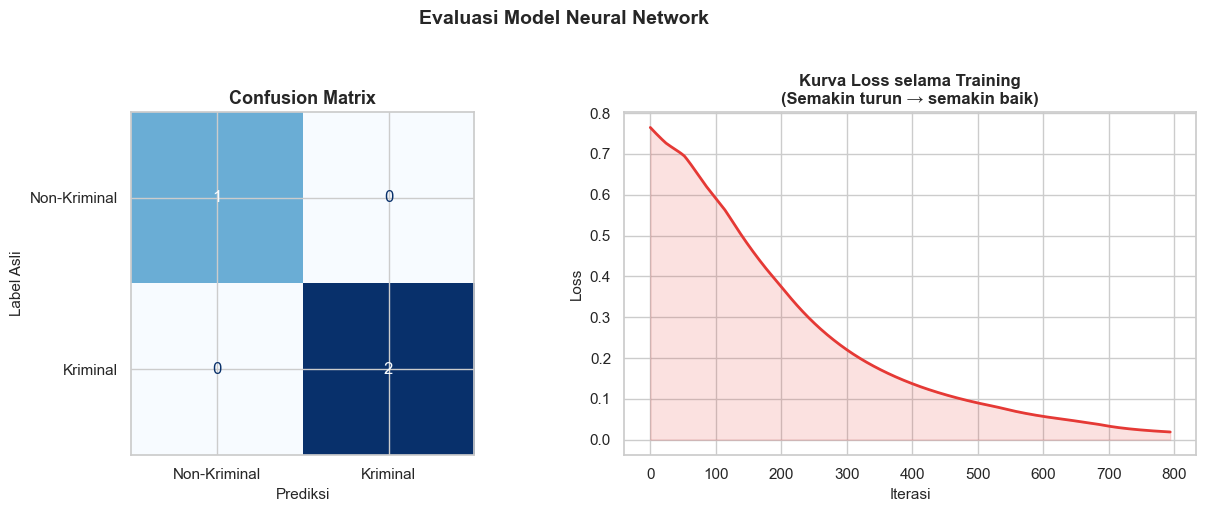

📊 Visualisasi evaluasi model selesai!


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Kriminal', 'Kriminal'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Prediksi', fontsize=11)
axes[0].set_ylabel('Label Asli', fontsize=11)

# --- Loss Curve ---
axes[1].plot(model.loss_curve_, color='#E53935', linewidth=2)
axes[1].set_xlabel('Iterasi', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('Kurva Loss selama Training\n(Semakin turun → semakin baik)', fontsize=12, fontweight='bold')
axes[1].fill_between(range(len(model.loss_curve_)), model.loss_curve_, alpha=0.15, color='#E53935')

plt.suptitle('Evaluasi Model Neural Network', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_evaluasi_model.png', bbox_inches='tight', dpi=120)
plt.show()
print('📊 Visualisasi evaluasi model selesai!')

---
## 13. Prediksi Berita Baru

Kita coba gunakan model yang sudah dilatih untuk memprediksi **3 judul berita baru** yang belum pernah dilihat model sebelumnya:

In [16]:
# Data berita baru
berita_baru = [
    {'judul': 'Pria Bersenjata Rampas Motor di Depan SPBU, Ditangkap Polisi',  'fitur': [3, 1, 3]},
    {'judul': 'Menteri Keuangan Bahas APBN 2025 bersama DPR',                  'fitur': [0, 3, 1]},
    {'judul': 'Pegawai Bank Ditangkap karena Gelapkan Dana Nasabah Rp 2 M',    'fitur': [2, 2, 2]},
]

print('=' * 75)
print('              PREDIKSI BERITA BARU')
print('=' * 75)

for item in berita_baru:
    fitur_arr = np.array([item['fitur']])
    fitur_scaled = scaler.transform(fitur_arr)
    pred = model.predict(fitur_scaled)[0]
    prob = model.predict_proba(fitur_scaled)[0]
    label_pred = '🔴 Kriminal' if pred == 1 else '🟢 Non-Kriminal'
    print(f' Judul   : {item["judul"]}')
    print(f'   Fitur   : kata_kriminal={item["fitur"][0]}, kata_umum={item["fitur"][1]}, kata_urgensi={item["fitur"][2]}')
    print(f'   Prediksi: {label_pred}  (Prob. Non-Kriminal: {prob[0]:.2f} | Kriminal: {prob[1]:.2f})')
    print()

              PREDIKSI BERITA BARU
 Judul   : Pria Bersenjata Rampas Motor di Depan SPBU, Ditangkap Polisi
   Fitur   : kata_kriminal=3, kata_umum=1, kata_urgensi=3
   Prediksi: 🔴 Kriminal  (Prob. Non-Kriminal: 0.00 | Kriminal: 1.00)

 Judul   : Menteri Keuangan Bahas APBN 2025 bersama DPR
   Fitur   : kata_kriminal=0, kata_umum=3, kata_urgensi=1
   Prediksi: 🟢 Non-Kriminal  (Prob. Non-Kriminal: 1.00 | Kriminal: 0.00)

 Judul   : Pegawai Bank Ditangkap karena Gelapkan Dana Nasabah Rp 2 M
   Fitur   : kata_kriminal=2, kata_umum=2, kata_urgensi=2
   Prediksi: 🔴 Kriminal  (Prob. Non-Kriminal: 0.05 | Kriminal: 0.95)



---
## 14. Kesimpulan

### Mengapa Neural Network Lebih Cocok dibanding Model Sederhana?

Berikut perbandingan singkat antara model sederhana (misal: perceptron tunggal) dan neural network:

| Aspek | Perceptron Sederhana | Multi-Layer Neural Network |
|-------|---------------------|----------------------------|
| Lapisan | 1 (langsung input → output) | 3+ layer (input → hidden → output) |
| Pola yang bisa dipelajari | Linear saja | Linear dan non-linear |
| Kemampuan kombinasi fitur | Terbatas | Bisa belajar kombinasi kompleks |
| Cocok untuk | Data sederhana | Data teks, gambar, suara |

### Ringkasan Alur Belajar Neural Network pada Kasus Ini:

1. **Input** → 3 fitur numerik masuk ke input layer: `kata_kriminal`, `kata_umum`, `kata_urgensi`
2. **Forward Propagation** → Data mengalir dari input → hidden layer 1 (5 neuron) → hidden layer 2 (3 neuron) → output, setiap neuron menghitung `z = Wx + b` lalu diaktivasi dengan ReLU/Sigmoid
3. **Output** → Model menghasilkan probabilitas: apakah berita termasuk Kriminal atau Non-Kriminal
4. **Error / Loss** → Prediksi dibandingkan label asli, dihitung Binary Cross-Entropy Loss
5. **Backpropagation** → Error dikirim mundur, menghitung seberapa besar kontribusi tiap bobot terhadap kesalahan
6. **Gradient Descent** → Bobot diperbarui menggunakan optimizer Adam agar loss semakin kecil
7. **Iterasi** → Langkah 1–6 diulang sampai model konvergen (loss stabil kecil)

### Kenapa Neural Network lebih cocok untuk kasus judul berita?

Karena sebuah judul berita mengandung sinyal yang kompleks dan tidak selalu bisa dipisahkan dengan garis lurus sederhana. Contoh nyata dari dataset kita:
- *"Pejabat Tembak Sapi Kurban Idul Adha Pakai Senapan"* → punya kata `tembak` dan `senapan` tapi labelnya **Non-Kriminal**, karena konteksnya kegiatan kurban
- Perceptron sederhana akan salah karena hanya melihat nilai fitur secara langsung
- Neural network dengan hidden layer mampu mempelajari **kombinasi** dari ketiga fitur secara bersamaan, sehingga lebih akurat menangkap pola yang ambigu seperti ini